# NetWatch — exploratory data analysis

Handbook task t5: class counts, feature distributions and correlated features, plus one
question that decides how we evaluate: **are flows inside one time block near-duplicates?**
If they are, a random train/test split leaks and inflates every score, which is why the
pipeline splits by 5-minute blocks.

Exploration only: nothing reported in the deck or model card comes from this notebook.
Every number here is recomputed from `data/processed/` when the notebook runs, so after the
real CICIDS2017 files are processed, re-run it:

```
make eda        # or: python -m nbconvert --to notebook --execute --inplace ml/notebooks/eda.ipynb
```
Needs `pip install -r requirements-dev.txt`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "ml" / "config.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from ml.features.select import feature_columns

cfg = yaml.safe_load(open(ROOT / "ml" / "config.yaml"))
df = pd.read_pickle(ROOT / cfg["paths"]["processed"])
features = feature_columns(df)
raw_files = sorted(p.name for p in (ROOT / cfg["paths"]["raw_dir"]).glob("*.csv"))
SYNTHETIC = any(name.lower().startswith("synthetic") for name in raw_files)

plt.rcParams.update({"figure.dpi": 80, "axes.grid": True, "grid.alpha": 0.3})
print(f"{len(df):,} flows, {len(features)} features, source files: {raw_files}")
print("DATA:", "SYNTHETIC (scripts/make_synthetic.py) — not CICIDS2017" if SYNTHETIC else "CICIDS2017")
print("time range:", df["Timestamp"].min(), "->", df["Timestamp"].max())

60,000 flows, 13 features, source files: ['Synthetic-WorkingHours.pcap_ISCX.csv']
DATA: SYNTHETIC (scripts/make_synthetic.py) — not CICIDS2017
time range: 2017-07-07 08:00:00 -> 2017-07-07 15:59:59


## 1. Class counts

Per family, and the share of all flows. Macro-F1 exists because of this table.

,flows,share
family,,
Benign,36000,0.600
DoS,7200,0.120
PortScan,6000,0.100
DDoS,5400,0.090
BruteForce,2400,0.040
Bot,1200,0.020
WebAttack,1200,0.020
Infiltration,300,0.005
Heartbleed,300,0.005


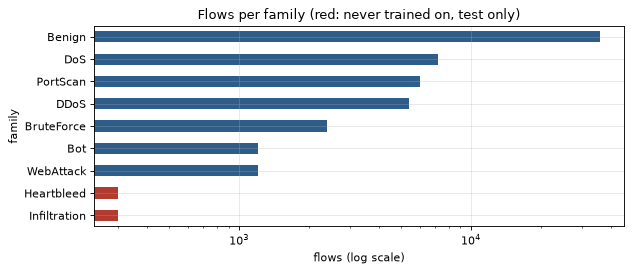

benign share 60.0%: a model that never alerts scores 60.0% accuracy


In [2]:
counts = df["family"].value_counts()
table = pd.DataFrame({"flows": counts, "share": (counts / len(df)).round(4)})
display(table)

fig, ax = plt.subplots(figsize=(8, 3.5))
counts.sort_values().plot.barh(ax=ax, logx=True, color=["#B23A2E" if f in ("Infiltration", "Heartbleed") else "#2F5D8A" for f in counts.sort_values().index])
ax.set_xlabel("flows (log scale)")
ax.set_title("Flows per family (red: never trained on, test only)")
plt.tight_layout(); plt.show()

benign_share = counts.get("Benign", 0) / len(df)
print(f"benign share {benign_share:.1%}: a model that never alerts scores {benign_share:.1%} accuracy")

## 2. Feature distributions

Flow features span orders of magnitude, so they are shown after `log1p` — the same scaling the anomaly detector uses.

In [3]:
desc = df[features].describe(percentiles=[0.5, 0.99]).T[["min", "50%", "99%", "max"]]
desc["zero_share"] = (df[features] == 0).mean().round(3)
desc["max_over_median"] = (desc["max"] / desc["50%"].replace(0, np.nan)).round(1)
display(desc)

,min,50%,99%,max,zero_share,max_over_median
ACK Flag Count,1.018539,148.655701,3147.697170,29732.845703,0.0,200.0
Bwd Packet Length Mean,1.618097,145.363556,3205.152554,17767.191406,0.0,122.2
Destination Port,21.000000,80.000000,8080.000000,8080.000000,0.0,101.0
Flow Bytes/s,1.855824,146.811844,3284.764187,32927.484375,0.0,224.3
Flow Duration,1.492229,147.872627,3344.684248,23494.849609,0.0,158.9
Flow IAT Mean,1.822405,147.212097,3302.450813,22855.687500,0.0,155.3
Flow IAT Std,2.101989,146.191605,3274.209529,35010.585938,0.0,239.5
Flow Packets/s,1.300316,145.526703,3215.419158,30687.052734,0.0,210.9
Fwd Packet Length Mean,1.749583,146.472466,3257.300994,35218.875000,0.0,240.4
Packet Length Variance,1.449628,146.015442,3144.087847,34571.039062,0.0,236.8


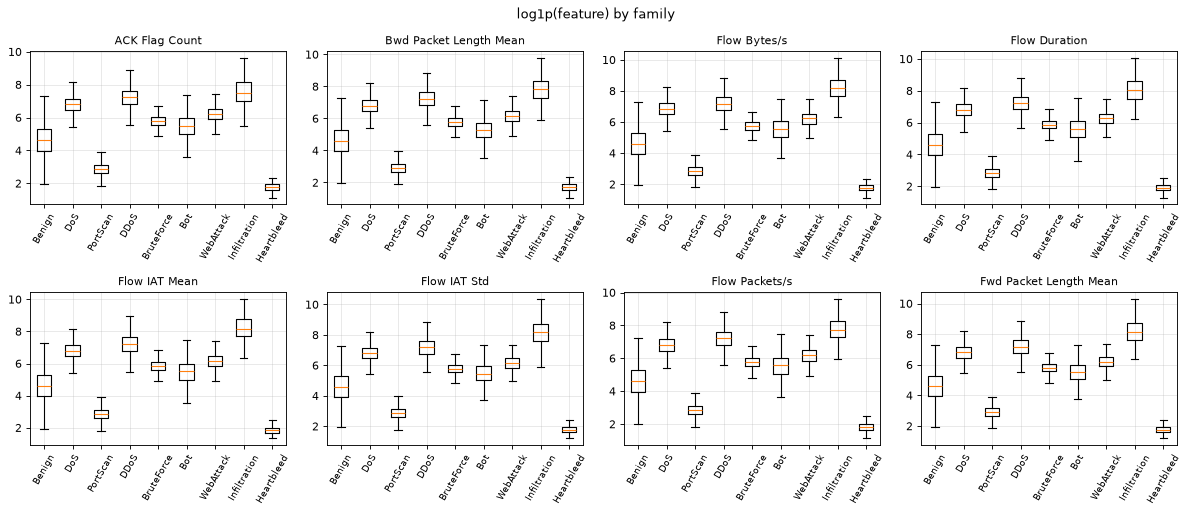

In [4]:
show = [f for f in features if f != "Destination Port"][:8]
fams = counts.index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=False)
for ax, feat in zip(axes.ravel(), show):
    data = [np.log1p(df.loc[df["family"] == f, feat].clip(lower=0)) for f in fams]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(fams) + 1), fams, rotation=60, fontsize=8)
    ax.set_title(feat, fontsize=10)
fig.suptitle("log1p(feature) by family")
plt.tight_layout(); plt.show()

## 3. Correlated features

Pairs above |r| = 0.95 (on log1p values) carry the same information; `ml/features/select.py` prunes them at that threshold.

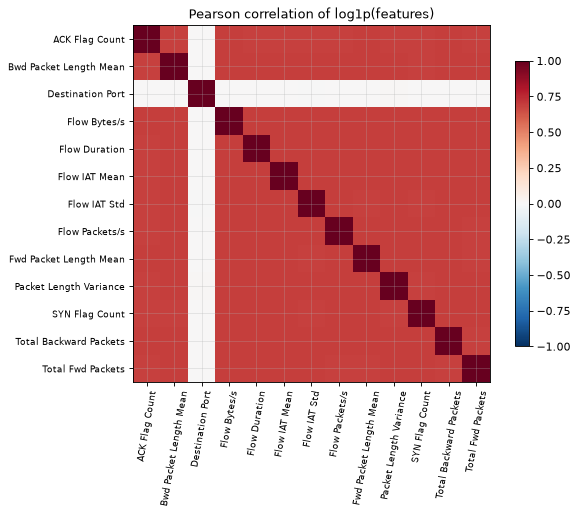

0 pairs above |r| 0.95: none
strongest pairs: [('Flow Bytes/s', 'Flow IAT Mean', np.float64(0.694)), ('Flow Packets/s', 'Total Backward Packets', np.float64(0.694)), ('Flow Bytes/s', 'Packet Length Variance', np.float64(0.694)), ('Flow Duration', 'Flow IAT Mean', np.float64(0.694)), ('Flow Duration', 'Total Backward Packets', np.float64(0.693))]


In [5]:
logf = np.log1p(df[features].clip(lower=0))
corr = logf.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(features)), features, rotation=80, fontsize=8)
ax.set_yticks(range(len(features)), features, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Pearson correlation of log1p(features)")
plt.tight_layout(); plt.show()

pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(features) for b in features[i + 1:]]
strong = sorted([p for p in pairs if abs(p[2]) > 0.95], key=lambda p: -abs(p[2]))
top = sorted(pairs, key=lambda p: -abs(p[2]))[:5]
print(f"{len(strong)} pairs above |r| 0.95:", [(a, b, round(r, 3)) for a, b, r in strong] or "none")
print("strongest pairs:", [(a, b, round(r, 3)) for a, b, r in top])

## 4. Time blocks and near-duplicates

For each attack family: how close is each flow to its nearest neighbour **in the same 5-minute
block**, compared with its nearest neighbour among **as many flows drawn from other blocks**?
(Standardised log1p space. The pools are the same size: a nearest neighbour found in a bigger
pool is closer by chance alone.)

If same-block neighbours are much closer, bursts are near-duplicates: a random split would put
copies of one burst in train and test, and the score would be inflated. The time-block split
avoids that either way; this measures how much it matters on this data.

In [6]:
block = df["day"].astype(str) + "_" + df["Timestamp"].dt.floor(f"{cfg['split']['block_minutes']}min").astype(str)
Z = (logf - logf.mean()) / logf.std().replace(0, 1)
rng = np.random.default_rng(0)
rows = []
for fam in [f for f in fams if f != "Benign"]:
    idx = np.flatnonzero(df["family"].to_numpy() == fam)
    if len(idx) < 50:
        continue
    X, b = Z.to_numpy()[idx], block.to_numpy()[idx]
    same, other = [], []
    for p in rng.choice(len(idx), size=min(300, len(idx)), replace=False):
        in_block = np.flatnonzero(b == b[p])
        in_block = in_block[in_block != p]
        elsewhere = np.flatnonzero(b != b[p])
        if len(in_block) == 0 or len(elsewhere) < len(in_block):
            continue
        pool = rng.choice(elsewhere, size=len(in_block), replace=False)
        same.append(np.linalg.norm(X[in_block] - X[p], axis=1).min())
        other.append(np.linalg.norm(X[pool] - X[p], axis=1).min())
    rows.append({"family": fam, "blocks": len(set(b)),
                 "median NN distance, same block": round(float(np.median(same)), 3) if same else np.nan,
                 "median NN distance, other block": round(float(np.median(other)), 3) if other else np.nan})
nd = pd.DataFrame(rows).set_index("family")
# > 1: flows in the same block are closer to each other than to equally many flows elsewhere
nd["ratio other/same"] = (nd.iloc[:, 2] / nd.iloc[:, 1]).round(2)
display(nd)
print("flows per block: median", int(block.value_counts().median()), "| blocks:", block.nunique())

,blocks,"median NN distance, same block","median NN distance, other block",ratio other/same
family,,,,
DoS,96,1.094,1.099,1.00
PortScan,96,0.845,0.874,1.03
DDoS,96,1.351,1.358,1.01
BruteForce,96,0.899,0.914,1.02
Bot,96,1.826,1.854,1.02
WebAttack,96,1.216,1.232,1.01
Infiltration,90,2.438,2.432,1.00
Heartbleed,94,0.901,0.890,0.99


flows per block: median 625 | blocks: 96


## 5. Data quality after cleaning

In [7]:
num = df[features]
quality = {
    "rows": len(df),
    "NaN cells": int(num.isna().sum().sum()),
    "inf cells": int(np.isinf(num.to_numpy()).sum()),
    "duplicate rows": int(df.duplicated().sum()),
    "constant features": [c for c in features if num[c].nunique() <= 1],
    "negative values": {c: int((num[c] < 0).sum()) for c in features if (num[c] < 0).any()},
}
quality

{'rows': 60000,
 'NaN cells': 0,
 'inf cells': 0,
 'duplicate rows': 0,
 'constant features': [],
 'negative values': {}}

## Findings

Printed from the numbers above, so they stay true when the notebook is re-run on other data.

In [8]:
print("data:", "SYNTHETIC — re-run on CICIDS2017 before quoting anything" if SYNTHETIC else "CICIDS2017")
rare = table[table["share"] < 0.01].index.tolist()
print(f"- benign is {benign_share:.1%} of flows; families under 1%: {rare}")
print(f"- {len(strong)} feature pairs above |r| 0.95")
ratio = nd["ratio other/same"].median()
if ratio > 2:
    print(f"- same-block neighbours are ~{ratio:.1f}x closer than other-block ones: bursts are near-duplicates, "
          "so a random split would leak; the time-block split is essential")
else:
    print(f"- same-block neighbours are ~{ratio:.1f}x as close as equally many flows from other blocks: bursts are "
          "not concentrated in time blocks here, so a random split has little to leak (matches the naive-split "
          "result in the model card)")
issues = {k: v for k, v in quality.items() if k != "rows" and v not in (0, [], {})}
print("- data quality after cleaning:", issues or "no NaN, inf, duplicates, constant or negative features")

data: SYNTHETIC — re-run on CICIDS2017 before quoting anything
- benign is 60.0% of flows; families under 1%: ['Infiltration', 'Heartbleed']
- 0 feature pairs above |r| 0.95
- same-block neighbours are ~1.0x as close as equally many flows from other blocks: bursts are not concentrated in time blocks here, so a random split has little to leak (matches the naive-split result in the model card)
- data quality after cleaning: no NaN, inf, duplicates, constant or negative features
